# Handwritten Character Recognition

## Project Overview

This project uses deep learning and image processing techniques to recognize handwritten characters from grayscale images.

A Convolutional Neural Network (CNN) will be trained on a handwritten character dataset and evaluated using accuracy, loss, and other performance measures.

In [1]:
!pip install tensorflow tensorflow-datasets matplotlib seaborn scikit-learn

In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow version:", tf.__version__)

(train_data, test_data), dataset_info = tfds.load(
    "emnist/letters",
    split=["train", "test"],
    as_supervised=True,
    with_info=True
)

print("Dataset loaded successfully!")
print("Number of classes:", dataset_info.features["label"].num_classes)
print("Training examples:", dataset_info.splits["train"].num_examples)
print("Testing examples:", dataset_info.splits["test"].num_examples)

ERROR:absl:Detected incompatible Protobuf Gencode/Runtime versions when loading tensorflow_metadata/proto/v0/anomalies.proto: gencode 6.31.1 runtime 5.29.6. Runtime version cannot be older than the linked gencode version. See Protobuf version guarantees at https://protobuf.dev/support/cross-version-runtime-guarantee.
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/tensorflow_datasets/__init__.py", line 79, in <module>
    from tensorflow_datasets import rlds  # pylint: disable=g-bad-import-order
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/tensorflow_datasets/rlds/__init__.py", line 21, in <module>
    from tensorflow_datasets.rlds import envlogger_reader
  File "/usr/local/lib/python3.13/dist-packages/tensorflow_datasets/rlds/envlogger_reader.py", line 21, in <module>
    from tensorflow_datasets.core.utils.lazy_imports_utils import tree
  File "/usr/local/lib/python3.13/dist-packages/tensorflow_datasets/co

TensorFlow version: 2.20.0


AttributeError: module 'tensorflow_datasets' has no attribute 'load'

In [3]:
import tensorflow_datasets as tfds

print("TFDS location:", tfds.__file__)
print("TFDS version:", getattr(tfds, "__version__", "unknown"))
print("Has load:", hasattr(tfds, "load"))

TFDS location: /usr/local/lib/python3.13/dist-packages/tensorflow_datasets/__init__.py
TFDS version: unknown
Has load: False


In [4]:
import tensorflow_datasets as tfds

print("TFDS version:", tfds.__version__)
print("Has load:", hasattr(tfds, "load"))

AttributeError: module 'tensorflow_datasets' has no attribute '__version__'

In [5]:
!pip uninstall -y tensorflow-datasets

Found existing installation: tensorflow-datasets 4.9.10
Uninstalling tensorflow-datasets-4.9.10:
  Successfully uninstalled tensorflow-datasets-4.9.10


In [1]:
import os
import gzip
import numpy as np
import urllib.request

base_url = "https://huggingface.co/datasets/Heliosoph/EMNIST/resolve/main/"

files = [
    "emnist-letters-train-images-idx3-ubyte.gz",
    "emnist-letters-train-labels-idx1-ubyte.gz",
    "emnist-letters-test-images-idx3-ubyte.gz",
    "emnist-letters-test-labels-idx1-ubyte.gz"
]

for file in files:
    if not os.path.exists(file):
        print("Downloading:", file)
        urllib.request.urlretrieve(base_url + file, file)

print("All dataset files downloaded successfully! ✅")

Downloading: emnist-letters-train-images-idx3-ubyte.gz
Downloading: emnist-letters-train-labels-idx1-ubyte.gz
Downloading: emnist-letters-test-images-idx3-ubyte.gz
Downloading: emnist-letters-test-labels-idx1-ubyte.gz
All dataset files downloaded successfully! ✅


In [2]:
import gzip
import numpy as np

def load_images(filename):
    with gzip.open(filename, "rb") as f:
        # Read IDX header
        header = np.frombuffer(f.read(16), dtype=">u4")
        _, num_images, rows, cols = header

        # Read image data
        images = np.frombuffer(
            f.read(),
            dtype=np.uint8
        ).reshape(num_images, rows, cols)

    # EMNIST images are stored transposed
    return np.transpose(images, (0, 2, 1))


def load_labels(filename):
    with gzip.open(filename, "rb") as f:
        # Read IDX header
        header = np.frombuffer(f.read(8), dtype=">u4")
        _, num_labels = header

        # Read labels
        labels = np.frombuffer(
            f.read(),
            dtype=np.uint8
        )

    return labels


X_train = load_images("emnist-letters-train-images-idx3-ubyte.gz")
y_train = load_labels("emnist-letters-train-labels-idx1-ubyte.gz")

X_test = load_images("emnist-letters-test-images-idx3-ubyte.gz")
y_test = load_labels("emnist-letters-test-labels-idx1-ubyte.gz")

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", X_test.shape)
print("Testing labels:", y_test.shape)

Training images: (124800, 28, 28)
Training labels: (124800,)
Testing images: (20800, 28, 28)
Testing labels: (20800,)


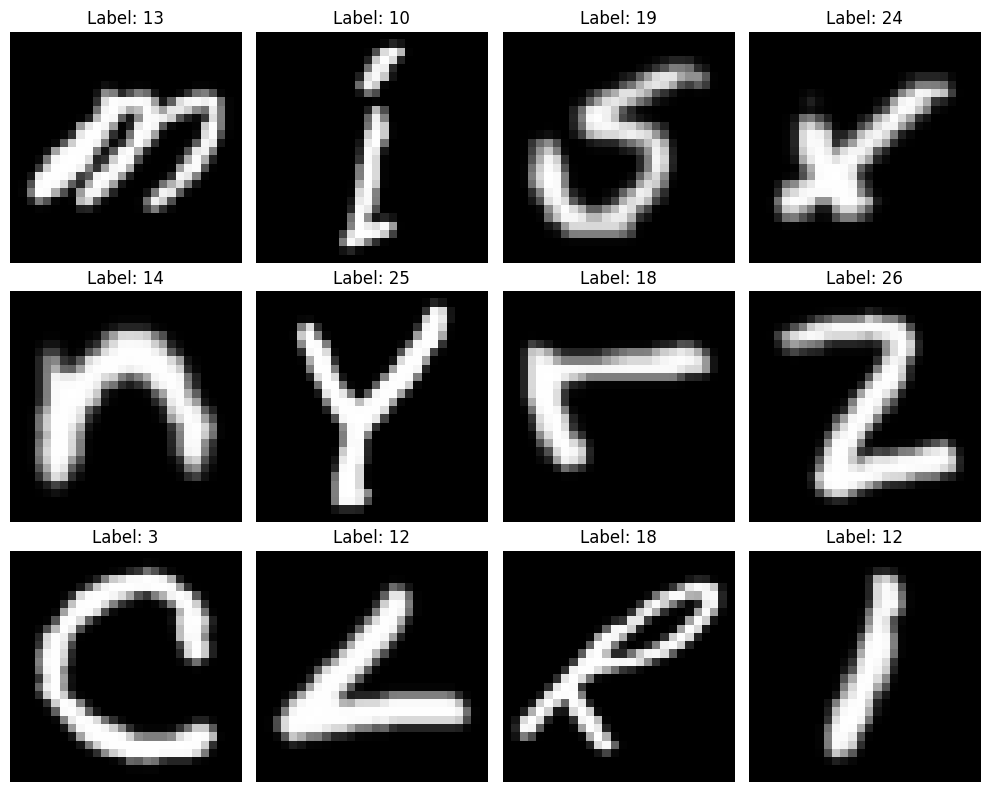

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Display 12 random training images
np.random.seed(42)
indices = np.random.choice(len(X_train), 12, replace=False)

plt.figure(figsize=(10, 8))

for i, idx in enumerate(indices):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_train[idx], cmap="gray")
    plt.title(f"Label: {y_train[idx]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
# Prepare data for CNN training

# Convert pixel values from 0-255 to 0-1
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Convert EMNIST labels from 1-26 to 0-25
y_train = y_train.astype("int64") - 1
y_test = y_test.astype("int64") - 1

# Add the channel dimension for CNN
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Number of character classes
num_classes = 26

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Pixel value range:", X_train.min(), "to", X_train.max())
print("Number of classes:", num_classes)
print("Label range:", y_train.min(), "to", y_train.max())

Training data shape: (124800, 28, 28, 1)
Testing data shape: (20800, 28, 28, 1)
Pixel value range: 0.0 to 1.0
Number of classes: 26
Label range: 0 to 25


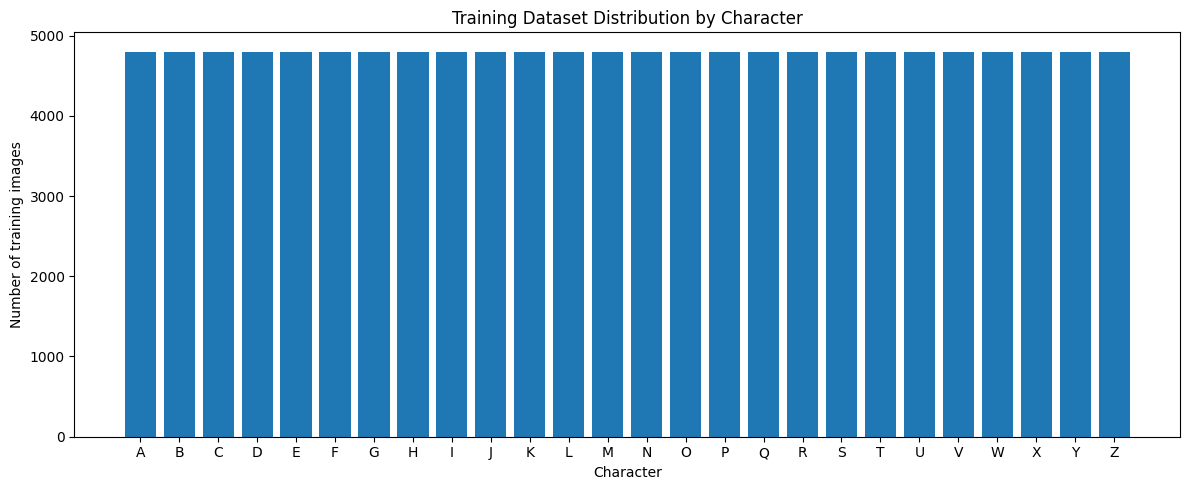

Total training images: 124800
Minimum images in a class: 4800
Maximum images in a class: 4800


In [5]:
# Check the distribution of all 26 character classes

import matplotlib.pyplot as plt
import numpy as np

class_counts = np.bincount(y_train, minlength=num_classes)

letters = [chr(ord("A") + i) for i in range(num_classes)]

plt.figure(figsize=(12, 5))
plt.bar(letters, class_counts)

plt.xlabel("Character")
plt.ylabel("Number of training images")
plt.title("Training Dataset Distribution by Character")
plt.xticks(letters)

plt.tight_layout()
plt.show()

print("Total training images:", len(y_train))
print("Minimum images in a class:", class_counts.min())
print("Maximum images in a class:", class_counts.max())

In [6]:
from sklearn.model_selection import train_test_split

# Create a validation set from the training data
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.10,
    random_state=42,
    stratify=y_train
)

print("Training data:", X_train.shape)
print("Validation data:", X_val.shape)
print("Test data:", X_test.shape)

Training data: (112320, 28, 28, 1)
Validation data: (12480, 28, 28, 1)
Test data: (20800, 28, 28, 1)


In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Build the Convolutional Neural Network
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    # First convolution block
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Second convolution block
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Third convolution block
    layers.Conv2D(128, (3, 3), activation="relu"),

    # Convert feature maps into a vector
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),

    # 26 output classes (A-Z)
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243,610 (951.60 KB)

 Trainable params: 243,610 (951.60 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    "best_handwritten_character_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

print("Training callbacks created successfully! ✅")

Training callbacks created successfully! ✅


In [9]:
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=128,
    validation_data=(X_val, y_val),
    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint
    ],
    verbose=1
)

Epoch 1/15
878/878 ━━━━━━━━━━━━━━━━━━━━ 98s 109ms/step - accuracy: 0.7815 - loss: 0.7083 - val_accuracy: 0.9040 - val_loss: 0.3005 - learning_rate: 0.0010
Epoch 2/15
878/878 ━━━━━━━━━━━━━━━━━━━━ 96s 109ms/step - accuracy: 0.8985 - loss: 0.3155 - val_accuracy: 0.9297 - val_loss: 0.2223 - learning_rate: 0.0010
Epoch 3/15
878/878 ━━━━━━━━━━━━━━━━━━━━ 142s 109ms/step - accuracy: 0.9159 - loss: 0.2572 - val_accuracy: 0.9334 - val_loss: 0.2080 - learning_rate: 0.0010
Epoch 4/15
878/878 ━━━━━━━━━━━━━━━━━━━━ 141s 108ms/step - accuracy: 0.9248 - loss: 0.2257 - val_accuracy: 0.9375 - val_loss: 0.1921 - learning_rate: 0.0010
Epoch 5/15
878/878 ━━━━━━━━━━━━━━━━━━━━ 95s 108ms/step - accuracy: 0.9316 - loss: 0.2041 - val_accuracy: 0.9404 - val_loss: 0.1860 - learning_rate: 0.0010
Epoch 6/15
878/878 ━━━━━━━━━━━━━━━━━━━━ 98s 112ms/step - accuracy: 0.9367 - loss: 0.1850 - val_accuracy: 0.9387 - val_loss: 0.1932 - learning_rate: 0.0010
Epoch 7/15
878/878 ━━━━━━━━━━━━━━━━━━━━ 95s 108ms/step - accuracy: 0

In [10]:
# Check the best validation performance

best_epoch = np.argmax(history.history["val_accuracy"]) + 1
best_val_accuracy = max(history.history["val_accuracy"])

print("Best Epoch:", best_epoch)
print("Best Validation Accuracy:", f"{best_val_accuracy * 100:.2f}%")

Best Epoch: 12
Best Validation Accuracy: 94.73%


In [11]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    batch_size=128,
    verbose=1
)

print("Test Accuracy:", f"{test_accuracy * 100:.2f}%")
print("Test Loss:", f"{test_loss:.4f}")

163/163 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9447 - loss: 0.1761
Test Accuracy: 94.47%
Test Loss: 0.1761


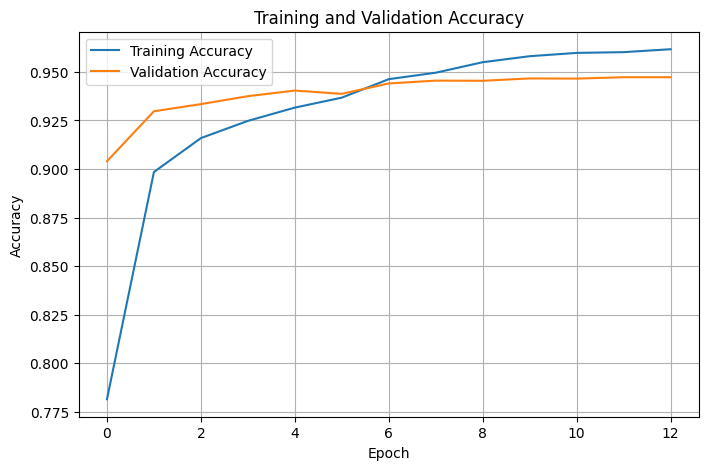

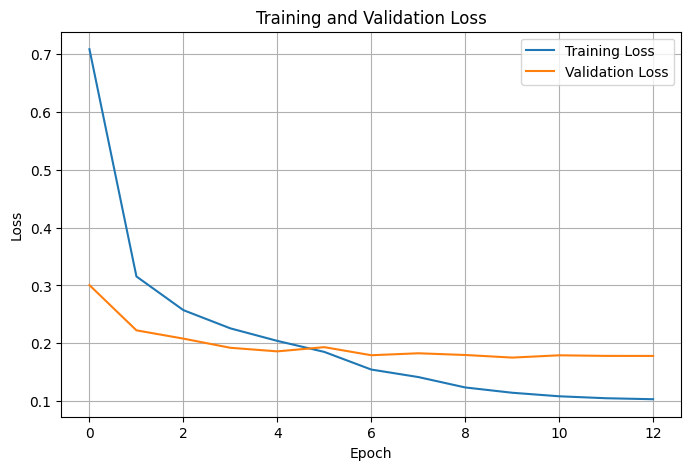

In [12]:
import matplotlib.pyplot as plt

# Accuracy curve
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss curve
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

163/163 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step


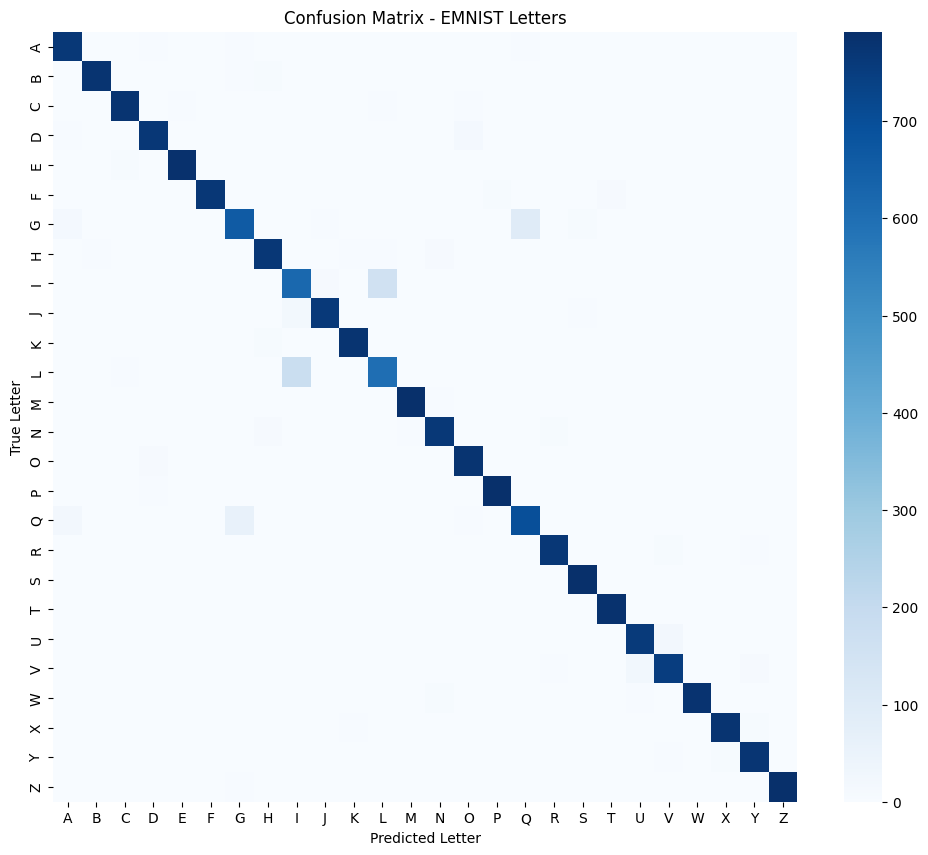

Classification Report:

              precision    recall  f1-score   support

           A      0.931     0.959     0.945       800
           B      0.984     0.971     0.977       800
           C      0.970     0.971     0.971       800
           D      0.960     0.963     0.961       800
           E      0.976     0.983     0.979       800
           F      0.987     0.963     0.975       800
           G      0.886     0.826     0.855       800
           H      0.951     0.961     0.956       800
           I      0.749     0.776     0.762       800
           J      0.960     0.954     0.957       800
           K      0.980     0.971     0.976       800
           L      0.772     0.754     0.763       800
           M      0.985     0.990     0.988       800
           N      0.960     0.958     0.959       800
           O      0.961     0.974     0.967       800
           P      0.980     0.990     0.985       800
           Q      0.863     0.871     0.867       800
   

In [13]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions for the test set
y_pred_prob = model.predict(X_test, batch_size=128, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=letters,
    yticklabels=letters
)
plt.xlabel("Predicted Letter")
plt.ylabel("True Letter")
plt.title("Confusion Matrix - EMNIST Letters")
plt.show()

# Classification Report
print("Classification Report:\n")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=letters,
        digits=3
    )
)

Total incorrect predictions: 1151
Error rate: 5.53%


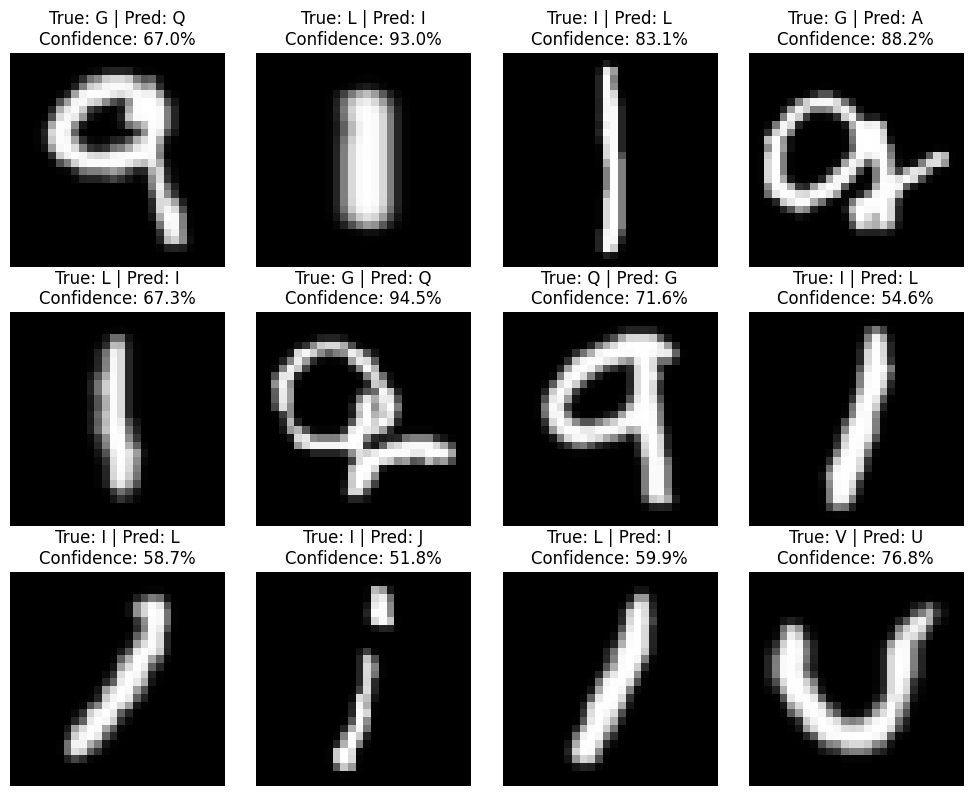

In [14]:
# Find incorrectly predicted test images
wrong_indices = np.where(y_pred != y_test)[0]

print("Total incorrect predictions:", len(wrong_indices))
print(
    "Error rate:",
    f"{len(wrong_indices) / len(y_test) * 100:.2f}%"
)

# Show 12 examples of incorrect predictions
np.random.seed(42)
sample_wrong = np.random.choice(
    wrong_indices,
    size=12,
    replace=False
)

plt.figure(figsize=(10, 8))

for i, idx in enumerate(sample_wrong):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[idx].squeeze(), cmap="gray")

    true_letter = letters[y_test[idx]]
    predicted_letter = letters[y_pred[idx]]

    confidence = y_pred_prob[idx][y_pred[idx]] * 100

    plt.title(
        f"True: {true_letter} | Pred: {predicted_letter}\n"
        f"Confidence: {confidence:.1f}%"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

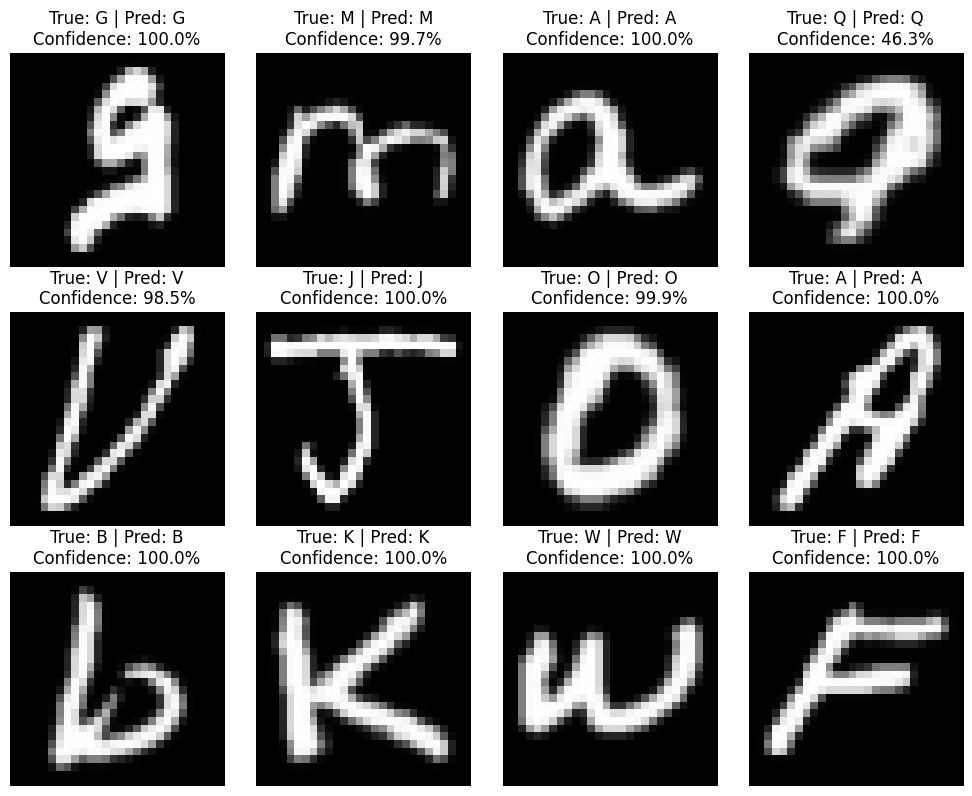

In [15]:
# Show correctly predicted examples
np.random.seed(10)

correct_indices = np.where(y_pred == y_test)[0]

sample_correct = np.random.choice(
    correct_indices,
    size=12,
    replace=False
)

plt.figure(figsize=(10, 8))

for i, idx in enumerate(sample_correct):
    plt.subplot(3, 4, i + 1)

    plt.imshow(X_test[idx].squeeze(), cmap="gray")

    true_letter = letters[y_test[idx]]
    predicted_letter = letters[y_pred[idx]]
    confidence = y_pred_prob[idx][y_pred[idx]] * 100

    plt.title(
        f"True: {true_letter} | Pred: {predicted_letter}\n"
        f"Confidence: {confidence:.1f}%"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
# Save the best trained CNN model
model.save("handwritten_character_cnn.keras")

print("Model saved successfully! ✅")

Model saved successfully! ✅


In [17]:
from PIL import Image
import numpy as np

def preprocess_uploaded_image(image):
    # Convert to grayscale
    image = image.convert("L")

    # Resize to the model's input size
    image = image.resize((28, 28))

    # Convert to NumPy array
    image = np.array(image).astype("float32") / 255.0

    # Add channel dimension
    image = image.reshape(1, 28, 28, 1)

    return image

print("Image preprocessing function created successfully! ✅")


Image preprocessing function created successfully! ✅


In [18]:
!pip install -q gradio

import gradio as gr
import numpy as np

def predict_character(image):
    if image is None:
        return "Please upload an image.", {}

    processed_image = preprocess_uploaded_image(image)

    # Get model predictions
    probabilities = model.predict(processed_image, verbose=0)[0]

    predicted_index = np.argmax(probabilities)
    predicted_letter = letters[predicted_index]
    confidence = probabilities[predicted_index] * 100

    # Top 3 predictions
    top_indices = np.argsort(probabilities)[-3:][::-1]

    top_predictions = {
        letters[i]: float(probabilities[i])
        for i in top_indices
    }

    result = f"Predicted Letter: {predicted_letter}\nConfidence: {confidence:.2f}%"

    return result, top_predictions


demo = gr.Interface(
    fn=predict_character,
    inputs=gr.Image(type="pil", label="Upload a handwritten character"),
    outputs=[
        gr.Textbox(label="Prediction"),
        gr.Label(num_top_classes=3, label="Top 3 Predictions")
    ],
    title="Handwritten Character Recognition",
    description="Upload a handwritten letter (A–Z) and the CNN will predict the character."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d9d3ff495cd3d97175.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [19]:
import json

with open("class_labels.json", "w") as f:
    json.dump(letters, f)

print("Class labels saved successfully! ✅")
print(letters)

Class labels saved successfully! ✅
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


In [20]:
from PIL import Image, ImageOps
import numpy as np

def preprocess_uploaded_image(image):
    # Convert to grayscale
    image = image.convert("L")

    # Convert to NumPy array
    image_array = np.array(image)

    # Automatically invert if the background is bright
    if image_array.mean() > 127:
        image_array = 255 - image_array

    # Find the handwritten character
    coords = np.argwhere(image_array > 30)

    if coords.size > 0:
        y_min, x_min = coords.min(axis=0)
        y_max, x_max = coords.max(axis=0)

        # Crop around the character
        image_array = image_array[y_min:y_max + 1, x_min:x_max + 1]

    # Convert back to PIL
    image = Image.fromarray(image_array)

    # Keep some space around the character
    image.thumbnail((20, 20))

    # Create a 28x28 black canvas
    canvas = Image.new("L", (28, 28), 0)

    # Center the character
    x = (28 - image.width) // 2
    y = (28 - image.height) // 2

    canvas.paste(image, (x, y))

    # Normalize
    image_array = np.array(canvas).astype("float32") / 255.0

    # Add batch and channel dimensions
    image_array = image_array.reshape(1, 28, 28, 1)

    return image_array

print("Improved image preprocessing created successfully! ✅")

Improved image preprocessing created successfully! ✅


In [21]:
!pip install -q gradio

import gradio as gr
import numpy as np

def predict_character(image):
    if image is None:
        return "Please upload an image.", {}

    processed_image = preprocess_uploaded_image(image)

    # Get model predictions
    probabilities = model.predict(processed_image, verbose=0)[0]

    predicted_index = np.argmax(probabilities)
    predicted_letter = letters[predicted_index]
    confidence = probabilities[predicted_index] * 100

    # Top 3 predictions
    top_indices = np.argsort(probabilities)[-3:][::-1]

    top_predictions = {
        letters[i]: float(probabilities[i])
        for i in top_indices
    }

    result = f"Predicted Letter: {predicted_letter}\nConfidence: {confidence:.2f}%"

    return result, top_predictions


demo = gr.Interface(
    fn=predict_character,
    inputs=gr.Image(type="pil", label="Upload a handwritten character"),
    outputs=[
        gr.Textbox(label="Prediction"),
        gr.Label(num_top_classes=3, label="Top 3 Predictions")
    ],
    title="Handwritten Character Recognition",
    description="Upload a handwritten letter (A–Z) and the CNN will predict the character."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3b3a74a0870eae90fc.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
